In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
corpus_df = pd.read_csv("data/full_corpus.csv")
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/public_test.csv")

In [3]:
print("Corpus:")
print(corpus_df.tail())
corpus_df.dtypes

Corpus:
                                                     text     cid
261789  Vi phạm quy định về an toàn, an ninh, trật tự,...  149611
261790  Nhiệm vụ, quyền hạn của Kiểm lâm cấp tỉnh\n1. ...  215427
261791  Đối tượng, điều kiện nhận hỗ trợ, tài trợ\n......  191823
261792  Viện trưởng Viện kiểm sát quân sự quân khu và ...  141170
261793  "Điều 17. Cấp Chứng chỉ hành nghề luật sư\n1. ...  147105


text    object
cid      int64
dtype: object

In [4]:
cids=corpus_df["cid"].to_list()

In [5]:
max(cids)

645446

In [6]:
print("\nTrain:")
print(train_df.head(20))


Train:
                                             question  \
0   Người học ngành quản lý khai thác công trình t...   
1   Nội dung lồng ghép vấn đề bình đẳng giới trong...   
2   Sản phẩm phần mềm có được hưởng ưu đãi về thời...   
3   Điều kiện để giáo viên trong cơ sở giáo dục mầ...   
4   Nguyên tắc áp dụng phụ cấp ưu đãi nghề y tế th...   
5   Chi phí hoạt động dịch vụ của Ngân hàng Hợp tá...   
6   Người học ngành điện tàu thủy trình độ trung c...   
7   Hương ước có nội dung trái với phong tục tập q...   
8   Luật sư nước ngoài đã được cấp Giấy phép hành ...   
9   Xe ô tô chở rau cho gia đình có bắt buộc phải ...   
10  Chính sách rủi ro của công ty chứng khoán do a...   
11  Điều kiện để rút ngắn thời gian thử thách của ...   
12  Trách nhiệm của cơ quan quản lý nhà nước về bì...   
13  Tiêu chí để được công nhận là cơ sở công nghiệ...   
14  Đơn vị được lựa chọn thực hiện huấn luyện, bồi...   
15  Mức đóng bảo hiểm xã hội tự nguyện hiện nay đư...   
16  Bột cánh cẳng bàn t

In [7]:
import ast
len(ast.literal_eval(train_df["context"][7]))


1

In [8]:
train_df["context"][7]

'[\'"Điều 15. Tạm ngừng thực hiện hương ước, quy ước\\n1. Hương ước, quy ước bị tạm ngừng thực hiện một phần hoặc toàn bộ khi thuộc một trong các trường hợp sau đây:\\na) Có nội dung quy định tại điểm a Khoản 1 Điều 10 của Quyết định này và nếu áp dụng sẽ gây ra thiệt hại hoặc có nguy cơ gây hậu quả nghiêm trọng;\\nb) Chưa được Ủy ban nhân dân cấp huyện công nhận mà vẫn thực hiện.\\n2. Khi có căn cứ quy định tại điểm a hoặc điểm b Khoản 1 Điều này, trong thời hạn 03 ngày làm việc, Ủy ban nhân dân cấp huyện ra quyết định tạm ngừng thực hiện hương ước, quy ước; chỉ đạo Ủy ban nhân dân cấp xã hướng dẫn thôn, tổ dân phố tiến hành việc sửa đổi, bổ sung, thay thế khi thuộc trường hợp quy định tại điểm a Khoản 1 Điều này hoặc tiến hành các thủ tục đề nghị công nhận theo quy định khi thuộc trường hợp quy định tại điểm b Khoản 1 Điều này.\\n3. Quyết định tạm ngừng thực hiện hương ước, quy ước phải quy định rõ thời hạn thực hiện việc sửa đổi, bổ sung, thay thế hoặc hoàn tất các thủ tục đề nghị c

In [9]:
print(train_df["context"][7])

['"Điều 15. Tạm ngừng thực hiện hương ước, quy ước\n1. Hương ước, quy ước bị tạm ngừng thực hiện một phần hoặc toàn bộ khi thuộc một trong các trường hợp sau đây:\na) Có nội dung quy định tại điểm a Khoản 1 Điều 10 của Quyết định này và nếu áp dụng sẽ gây ra thiệt hại hoặc có nguy cơ gây hậu quả nghiêm trọng;\nb) Chưa được Ủy ban nhân dân cấp huyện công nhận mà vẫn thực hiện.\n2. Khi có căn cứ quy định tại điểm a hoặc điểm b Khoản 1 Điều này, trong thời hạn 03 ngày làm việc, Ủy ban nhân dân cấp huyện ra quyết định tạm ngừng thực hiện hương ước, quy ước; chỉ đạo Ủy ban nhân dân cấp xã hướng dẫn thôn, tổ dân phố tiến hành việc sửa đổi, bổ sung, thay thế khi thuộc trường hợp quy định tại điểm a Khoản 1 Điều này hoặc tiến hành các thủ tục đề nghị công nhận theo quy định khi thuộc trường hợp quy định tại điểm b Khoản 1 Điều này.\n3. Quyết định tạm ngừng thực hiện hương ước, quy ước phải quy định rõ thời hạn thực hiện việc sửa đổi, bổ sung, thay thế hoặc hoàn tất các thủ tục đề nghị công nhậ

In [10]:
ctx_split = train_df["context"][7][2:-2].split("\'\n \'")

In [11]:
ctx_split[0]

'"Điều 15. Tạm ngừng thực hiện hương ước, quy ước\\n1. Hương ước, quy ước bị tạm ngừng thực hiện một phần hoặc toàn bộ khi thuộc một trong các trường hợp sau đây:\\na) Có nội dung quy định tại điểm a Khoản 1 Điều 10 của Quyết định này và nếu áp dụng sẽ gây ra thiệt hại hoặc có nguy cơ gây hậu quả nghiêm trọng;\\nb) Chưa được Ủy ban nhân dân cấp huyện công nhận mà vẫn thực hiện.\\n2. Khi có căn cứ quy định tại điểm a hoặc điểm b Khoản 1 Điều này, trong thời hạn 03 ngày làm việc, Ủy ban nhân dân cấp huyện ra quyết định tạm ngừng thực hiện hương ước, quy ước; chỉ đạo Ủy ban nhân dân cấp xã hướng dẫn thôn, tổ dân phố tiến hành việc sửa đổi, bổ sung, thay thế khi thuộc trường hợp quy định tại điểm a Khoản 1 Điều này hoặc tiến hành các thủ tục đề nghị công nhận theo quy định khi thuộc trường hợp quy định tại điểm b Khoản 1 Điều này.\\n3. Quyết định tạm ngừng thực hiện hương ước, quy ước phải quy định rõ thời hạn thực hiện việc sửa đổi, bổ sung, thay thế hoặc hoàn tất các thủ tục đề nghị công

In [12]:
err_question = dict()
ctx_len = []
cid_len = []

In [13]:
for i, r in train_df.iterrows():
    if isinstance(r["cid"], str):
        list_cid = r["cid"][1:-1].split() 
        list_ctx = r["context"][2:-2].split("\'\n \'")
        ctx_len.append(len(list_ctx))
        cid_len.append(len(list_cid))
        try:
            int_list = [int(x) for x in list_cid]
        except ValueError:
            print(f"Lỗi khi ép kiểu ở dòng {i}, giá trị cid: {r['cid']}")
            continue
    elif isinstance(r["cid"], list):
        int_list = r["cid"]
    else:
        continue

    miss_lst = [{"cid":idx, "text": ctx} for idx, ctx in zip(int_list, list_ctx) if idx not in cids]
    if len(miss_lst) != 0:
        print(f'Question {r["qid"]} has invalid contexts: {len(miss_lst)}')
        err_question[r["qid"]] = miss_lst[0]


KeyboardInterrupt: 

In [ ]:
max(cid_len)

9

In [14]:
existing_cids = set(corpus_df["cid"].astype(int).tolist())

unique_new_rows = []
seen_cids = set()

for item in err_question.values():
    cid = int(item["cid"])
    if cid not in seen_cids:
        unique_new_rows.append(item)
        seen_cids.add(cid)

new_rows_df = pd.DataFrame(unique_new_rows)

In [90]:
corpus_df = pd.concat([corpus_df, new_rows_df], ignore_index=True)

In [ ]:
corpus_df.to_csv("data/full_corpus.csv", index=False)

In [15]:
no_context_qids = train_df[train_df['cid'].apply(len) == 0]['qid']
print(f"Số lượng câu hỏi không có cid nào: {len(no_context_qids)}")
print("Danh sách các qid:", no_context_qids.tolist())

Số lượng câu hỏi không có cid nào: 0
Danh sách các qid: []


In [16]:
corpus_df

,text,cid
0,"Thông tư này hướng dẫn tuần tra, canh gác bảo ...",0
1,"1. Hàng năm trước mùa mưa, lũ, Ủy ban nhân dân...",1
2,Tiêu chuẩn của các thành viên thuộc lực lượng ...,2
3,"Nhiệm vụ của lực lượng tuần tra, canh gác đê\n...",3
4,"Phù hiệu của lực lượng tuần tra, canh gác đê\n...",4
...,...,...
261789,"Vi phạm quy định về an toàn, an ninh, trật tự,...",149611
261790,"Nhiệm vụ, quyền hạn của Kiểm lâm cấp tỉnh\n1. ...",215427
261791,"Đối tượng, điều kiện nhận hỗ trợ, tài trợ\n......",191823
261792,Viện trưởng Viện kiểm sát quân sự quân khu và ...,141170


In [23]:
corpus_df["text"][5].strip('\xa0')

'1. Lực lượng tuần tra, canh gác đê được trang bị:\n- Dụng cụ thông tin, liên lạc, phương tiện phục vụ công tác tuần tra, canh gác đê; dụng cụ ứng cứu như đèn, đuốc, mai, cuốc, xẻng, đầm, vồ… và các dụng cụ cần thiết khác phù hợp với từng địa phương;\n- Sổ sách để ghi chép tình hình diễn biến của đê, kè bảo vệ đê, cống qua đê, công trình quản lý khác; tiếp nhận chỉ thị, nhận xét của cấp trên, phân công, bố trí người tuần tra, canh gác hàng ngày.\n2. Số lượng dụng cụ, sổ sách tối thiểu được trang bị cho mỗi đội tuần tra, canh gác đê như sau:\na) Về dụng cụ:\n- Áo phao:\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0 06 cái;\n- Áo đi mưa:\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0 18 cái;\n- Xe cải tiến:\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0

In [ ]:
train_df['question_length'] = train_df['question'].str.split().apply(len)
print("Độ dài trung bình của question:", train_df['question_length'].mean())

test_df['question_length'] = test_df['question'].str.split().apply(len)
print("Độ dài trung bình của question trong public_test:", test_df['question_length'].mean())

corpus_df['text_length'] = corpus_df['text'].str.split().apply(len)
print("Độ dài trung bình của text trong corpus:", corpus_df['text_length'].mean())

cid_text_map = dict(zip(corpus_df['cid'], corpus_df['text']))

def get_context_text(cid_str):
    cids = cid_str.strip("[]").split()
    return " ".join([cid_text_map.get(int(cid), "") for cid in cids])

train_df['context_text'] = train_df['cid'].apply(get_context_text)

train_df['context_length'] = train_df['context_text'].str.split().apply(len)

print("Độ dài trung bình của context cho từng question:", train_df['context_length'].mean())


Độ dài trung bình của question: 20.262079761585856
Độ dài trung bình của question trong public_test: 20.2981
Độ dài trung bình của text trong corpus: 240.15875841310344
Độ dài trung bình của context cho từng question: 288.9308113447629


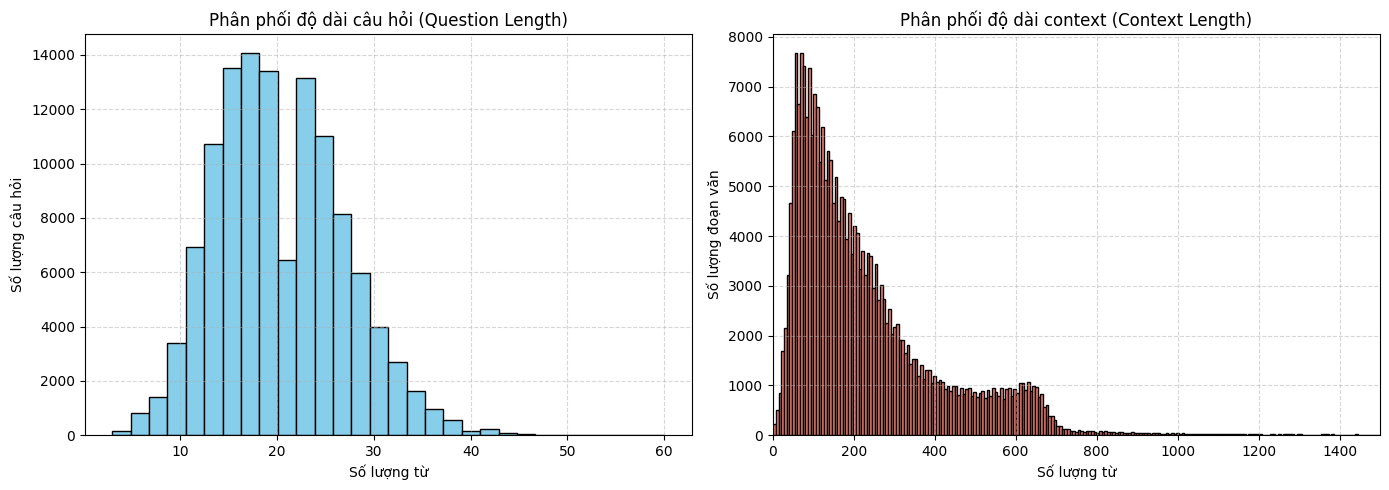

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 5))

# Biểu đồ 1: Question length (giữ nguyên như cũ)
plt.subplot(1, 2, 1)
plt.hist(train_df['question_length'], bins=30, color='skyblue', edgecolor='black')
plt.title("Phân phối độ dài câu hỏi (Question Length)")
plt.xlabel("Số lượng từ")
plt.ylabel("Số lượng câu hỏi")
plt.grid(True, linestyle='--', alpha=0.5)

# Biểu đồ 2: Context length (vẽ toàn bộ giá trị, chia bin hợp lý)
plt.subplot(1, 2, 2)

# Tạo bins theo kiểu log để phản ánh đúng phân phối lệch
bins = np.histogram_bin_edges(corpus_df['text_length'], bins='auto')  # hoặc thử 'fd', 'sturges', 'doane'

plt.hist(corpus_df['text_length'], bins=bins, color='salmon', edgecolor='black')
plt.title("Phân phối độ dài context (Context Length)")
plt.xlabel("Số lượng từ")
plt.ylabel("Số lượng đoạn văn")
plt.xlim(0, 1500)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


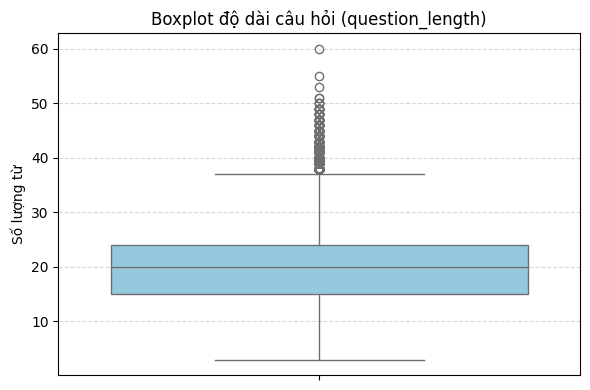

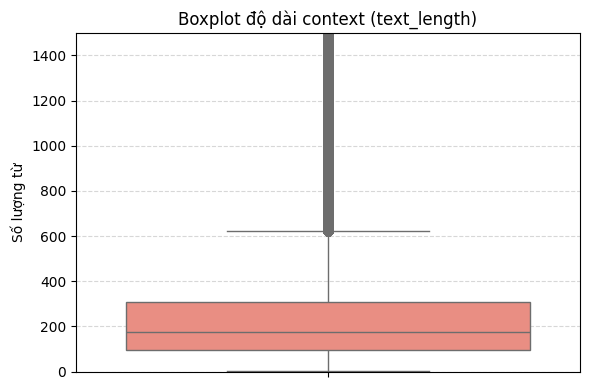

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Giả định train_df và corpus_df đã được định nghĩa
# Nếu không, bạn cần cung cấp dữ liệu để tôi có thể chạy code

# Boxplot 1: Question Length
plt.figure(figsize=(6, 4))
sns.boxplot(y=train_df["question_length"], color='skyblue')
plt.title("Boxplot độ dài câu hỏi (question_length)")
plt.ylabel("Số lượng từ")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Boxplot 2: Context Length (text_length) với giới hạn trục y từ 0 đến 1500
plt.figure(figsize=(6, 4))
sns.boxplot(y=corpus_df["text_length"], color='salmon')
plt.title("Boxplot độ dài context (text_length)")
plt.ylabel("Số lượng từ")
plt.ylim(0, 1500)  # Giới hạn trục y từ 0 đến 1500
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()